In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup Successful")

Setup Successful


In [2]:
nav_df = pd.read_csv("../data/processed/clean_nav_history.csv")

perf_df = pd.read_csv("../data/processed/clean_scheme_performance.csv")

benchmark_df = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [3]:
nav_df.head()

,amfi_code,date,nav
0,119551,03-01-2022,54.3856
1,119551,04-01-2022,54.3474
2,119551,05-01-2022,54.6869
3,119551,06-01-2022,55.4550
4,119551,07-01-2022,55.3692


In [4]:
nav_df.info()
perf_df.head()
benchmark_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [6]:
nav_df["date"] = pd.to_datetime(
    nav_df["date"],
    dayfirst=True
)

In [7]:
nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
)

In [8]:
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
          .pct_change()
)

In [9]:
nav_df.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [10]:
nav_df["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [11]:
nav_df.to_csv(
    "../data/processed/returns_computed.csv",
    index=False
)

print("returns_computed.csv saved successfully!")

returns_computed.csv saved successfully!


In [12]:
nav_df.groupby("amfi_code")["date"].agg(["min","max"]).head()

,min,max
amfi_code,,
100016,2022-01-03,2026-05-29
100025,2022-01-03,2026-05-29
100033,2022-01-03,2026-05-29
101206,2022-01-03,2026-05-29
101207,2022-01-03,2026-05-29


In [13]:
def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years) - 1) * 100

In [14]:
cagr_data = []

for code, group in nav_df.groupby("amfi_code"):

    group = group.sort_values("date")

    start_nav = group.iloc[0]["nav"]
    end_nav = group.iloc[-1]["nav"]

    years = (
        (group.iloc[-1]["date"] - group.iloc[0]["date"]).days
        / 365.25
    )

    cagr = calculate_cagr(start_nav, end_nav, years)

    cagr_data.append([code, round(cagr,2)])

cagr_df = pd.DataFrame(
    cagr_data,
    columns=["amfi_code","CAGR (%)"]
)

cagr_df.head()

,amfi_code,CAGR (%)
0,100016,2.64
1,100025,4.46
2,100033,30.12
3,101206,23.54
4,101207,7.94


In [15]:
cagr_df = cagr_df.merge(
    perf_df[["amfi_code","scheme_name"]],
    on="amfi_code",
    how="left"
)

cagr_df.head()

,amfi_code,CAGR (%),scheme_name
0,100016,2.64,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,4.46,HDFC Short Term Debt Fund - Regular - Growth
2,100033,30.12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,23.54,ABSL Frontline Equity Fund - Regular - Growth
4,101207,7.94,ABSL Small Cap Fund - Regular - Growth


In [16]:
cagr_df = cagr_df.sort_values(
    "CAGR (%)",
    ascending=False
)

cagr_df.head(10)

,amfi_code,CAGR (%),scheme_name
25,120505,32.83,ICICI Pru Midcap Fund - Regular - Growth
21,119598,32.42,SBI Small Cap Fund - Regular Plan - Growth
39,149324,32.29,DSP Small Cap Fund - Regular - Growth
36,148569,31.95,Mirae Asset Tax Saver Fund - Regular - Growth
34,148567,30.97,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,30.91,Kotak Flexicap Fund - Regular - Growth
2,100033,30.12,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
38,149323,29.58,DSP Midcap Fund - Regular - Growth
16,119094,28.21,Axis Midcap Fund - Regular - Growth
19,119551,25.80,SBI Bluechip Fund - Regular Plan - Growth


In [17]:
cagr_df.to_csv(
    "../data/processed/cagr_report.csv",
    index=False
)

print("cagr_report.csv saved successfully!")

cagr_report.csv saved successfully!


In [18]:
risk_free_rate = 0.065

In [19]:
annual_return = (
    nav_df.groupby("amfi_code")["daily_return"]
          .mean()
          * 252
)

In [20]:
annual_volatility = (
    nav_df.groupby("amfi_code")["daily_return"]
          .std()
          * np.sqrt(252)
)

In [21]:
sharpe_df = pd.DataFrame({
    "Annual Return": annual_return,
    "Annual Volatility": annual_volatility
})

sharpe_df["Sharpe Ratio"] = (
    (sharpe_df["Annual Return"] - risk_free_rate)
    / sharpe_df["Annual Volatility"]
)

sharpe_df.reset_index(inplace=True)

sharpe_df.head()

,amfi_code,Annual Return,Annual Volatility,Sharpe Ratio
0,100016,0.035683,0.145481,-0.201517
1,100025,0.042854,0.039052,-0.567095
2,100033,0.272111,0.189367,1.093699
3,101206,0.214647,0.145682,1.027213
4,101207,0.106962,0.257973,0.162661


In [22]:
sharpe_df = sharpe_df.merge(
    perf_df[["amfi_code","scheme_name"]],
    on="amfi_code",
    how="left"
)

sharpe_df.head()

,amfi_code,Annual Return,Annual Volatility,Sharpe Ratio,scheme_name
0,100016,0.035683,0.145481,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042854,0.039052,-0.567095,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.272111,0.189367,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.214647,0.145682,1.027213,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.106962,0.257973,0.162661,ABSL Small Cap Fund - Regular - Growth


In [23]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe Ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,Annual Return,Annual Volatility,Sharpe Ratio,scheme_name
34,148567,0.270566,0.141937,1.448291,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.272602,0.158870,1.306744,Kotak Flexicap Fund - Regular - Growth
36,148569,0.283262,0.176740,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,0.231033,0.137414,1.208267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,0.292653,0.192909,1.180101,ICICI Pru Midcap Fund - Regular - Growth
38,149323,0.265908,0.177462,1.132122,DSP Midcap Fund - Regular - Growth
2,100033,0.272111,0.189367,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,0.218037,0.141484,1.081659,Nippon India Large Cap Fund - Regular - Growth
3,101206,0.214647,0.145682,1.027213,ABSL Frontline Equity Fund - Regular - Growth
24,120504,0.212448,0.143638,1.026524,ICICI Pru Bluechip Fund - Direct - Growth


In [24]:
sharpe_df.to_csv(
    "../data/processed/sharpe_values.csv",
    index=False
)

print("Sharpe Ratio calculated successfully!")

Sharpe Ratio calculated successfully!


In [25]:
downside_returns = nav_df.copy()

downside_returns["downside_return"] = downside_returns["daily_return"].where(
    downside_returns["daily_return"] < 0
)

In [26]:
downside_deviation = (
    downside_returns.groupby("amfi_code")["downside_return"]
    .std()
    * np.sqrt(252)
)

downside_deviation.head()

amfi_code
100016    0.083513
100025    0.023514
100033    0.113229
101206    0.083157
101207    0.151683
Name: downside_return, dtype: float64

In [27]:
sortino_df = pd.DataFrame({
    "Annual Return": annual_return,
    "Downside Deviation": downside_deviation
})

sortino_df["Sortino Ratio"] = (
    (sortino_df["Annual Return"] - risk_free_rate)
    / sortino_df["Downside Deviation"]
)

sortino_df.reset_index(inplace=True)

sortino_df.head()

,amfi_code,Annual Return,Downside Deviation,Sortino Ratio
0,100016,0.035683,0.083513,-0.351047
1,100025,0.042854,0.023514,-0.941821
2,100033,0.272111,0.113229,1.829134
3,101206,0.214647,0.083157,1.799563
4,101207,0.106962,0.151683,0.276644


In [28]:
sortino_df = sortino_df.merge(
    perf_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

sortino_df.head()

,amfi_code,Annual Return,Downside Deviation,Sortino Ratio,scheme_name
0,100016,0.035683,0.083513,-0.351047,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042854,0.023514,-0.941821,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.272111,0.113229,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.214647,0.083157,1.799563,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.106962,0.151683,0.276644,ABSL Small Cap Fund - Regular - Growth


In [29]:
sortino_df = sortino_df.sort_values(
    "Sortino Ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,Annual Return,Downside Deviation,Sortino Ratio,scheme_name
34,148567,0.270566,0.086168,2.385644,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,0.272602,0.087806,2.364320,Kotak Flexicap Fund - Regular - Growth
36,148569,0.283262,0.101663,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,0.231033,0.077576,2.140267,SBI Bluechip Fund - Regular Plan - Growth
25,120505,0.292653,0.112180,2.029353,ICICI Pru Midcap Fund - Regular - Growth
38,149323,0.265908,0.107145,1.875101,DSP Midcap Fund - Regular - Growth
9,118632,0.218037,0.082717,1.850133,Nippon India Large Cap Fund - Regular - Growth
2,100033,0.272111,0.113229,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,0.212448,0.081675,1.805294,ICICI Pru Bluechip Fund - Direct - Growth
3,101206,0.214647,0.083157,1.799563,ABSL Frontline Equity Fund - Regular - Growth


In [30]:
sortino_df.to_csv(
    "../data/processed/sortino_values.csv",
    index=False
)

print("Sortino Ratio calculated successfully!")

Sortino Ratio calculated successfully!


In [32]:
benchmark_df.head()


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [33]:
benchmark_df["date"].head(10)

0    2022-01-03
1    2022-01-04
2    2022-01-05
3    2022-01-06
4    2022-01-07
5    2022-01-10
6    2022-01-11
7    2022-01-12
8    2022-01-13
9    2022-01-14
Name: date, dtype: str

In [34]:
benchmark_df["date"] = pd.to_datetime(
    benchmark_df["date"]
)

In [35]:
benchmark_df["date"] = pd.to_datetime(
    benchmark_df["date"],
    errors="coerce"
)

benchmark_df[benchmark_df["date"].isna()]

,date,index_name,close_value


In [36]:
benchmark_df.shape

(8050, 3)

In [37]:
benchmark_df.tail()

,date,index_name,close_value
8045,2026-05-25,CRISIL_GILT,2278.26
8046,2026-05-26,CRISIL_GILT,2281.42
8047,2026-05-27,CRISIL_GILT,2281.30
8048,2026-05-28,CRISIL_GILT,2298.35
8049,2026-05-29,CRISIL_GILT,2302.79


In [38]:
merged_df = pd.merge(
    nav_df,
    benchmark_df[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

merged_df.head()

KeyError: "['benchmark_return'] not in index"

In [39]:
benchmark_df.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [40]:
benchmark_df.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [42]:
benchmark_df["benchmark_return"] = benchmark_df["close_value"].pct_change()

In [43]:
benchmark_df.head()

,date,index_name,close_value,benchmark_return
0,2022-01-03,NIFTY50,17492.79,NaN
1,2022-01-04,NIFTY50,17689.64,0.011253
2,2022-01-05,NIFTY50,17835.05,0.008220
3,2022-01-06,NIFTY50,17878.51,0.002437
4,2022-01-07,NIFTY50,17759.15,-0.006676


In [44]:
merged_df = pd.merge(
    nav_df,
    benchmark_df[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

merged_df.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-03,520.4608,NaN,-0.039930
2,100016,2022-01-03,520.4608,NaN,-0.506415
3,100016,2022-01-03,520.4608,NaN,-0.189515
4,100016,2022-01-03,520.4608,NaN,-0.810673


In [45]:
results = []

for code, group in merged_df.groupby("amfi_code"):

    # Remove rows having NaN returns
    group = group.dropna(subset=["daily_return", "benchmark_return"])

    if len(group) < 2:
        continue

    beta = (
        group["daily_return"].cov(group["benchmark_return"])
        /
        group["benchmark_return"].var()
    )

    fund_return = group["daily_return"].mean() * 252
    benchmark_return = group["benchmark_return"].mean() * 252

    alpha = fund_return - (
        risk_free_rate +
        beta * (benchmark_return - risk_free_rate)
    )

    results.append([code, alpha, beta])

alpha_beta_df = pd.DataFrame(
    results,
    columns=["amfi_code", "Alpha", "Beta"]
)

alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,-0.029677,0.004843
1,100025,-0.021892,-0.003422
2,100033,0.205319,0.024097
3,101206,0.149652,-0.000067
4,101207,0.043716,-0.023588


In [46]:
alpha_beta_df = alpha_beta_df.merge(
    perf_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

alpha_beta_df.head()

,amfi_code,Alpha,Beta,scheme_name
0,100016,-0.029677,0.004843,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.021892,-0.003422,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.205319,0.024097,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.149652,-0.000067,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.043716,-0.023588,ABSL Small Cap Fund - Regular - Growth


In [47]:
alpha_beta_df.sort_values(
    by="Alpha",
    ascending=False
).head(10)

,amfi_code,Alpha,Beta,scheme_name
21,119598,0.237917,-0.003508,SBI Small Cap Fund - Regular Plan - Growth
39,149324,0.233204,0.036667,DSP Small Cap Fund - Regular - Growth
25,120505,0.228951,-0.017454,ICICI Pru Midcap Fund - Regular - Growth
36,148569,0.216950,0.017641,Mirae Asset Tax Saver Fund - Regular - Growth
30,120843,0.207927,-0.004370,Kotak Flexicap Fund - Regular - Growth
2,100033,0.205319,0.024097,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
34,148567,0.204787,0.010472,Mirae Asset Large Cap Fund - Regular - Growth
38,149323,0.200814,0.001259,DSP Midcap Fund - Regular - Growth
16,119094,0.195864,-0.028729,Axis Midcap Fund - Regular - Growth
19,119551,0.167906,-0.025189,SBI Bluechip Fund - Regular Plan - Growth


In [48]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("Alpha & Beta calculated successfully!")

Alpha & Beta calculated successfully!


In [49]:
nav_df = nav_df.sort_values(["amfi_code", "date"])

nav_df["running_peak"] = (
    nav_df.groupby("amfi_code")["nav"]
    .cummax()
)

nav_df.head()

,amfi_code,date,nav,daily_return,running_peak
5750,100016,2022-01-03,520.4608,NaN,520.4608
5751,100016,2022-01-04,515.0971,-0.010306,520.4608
5752,100016,2022-01-05,521.7239,0.012865,521.7239
5753,100016,2022-01-06,515.7880,-0.011377,521.7239
5754,100016,2022-01-07,515.1639,-0.001210,521.7239


In [50]:
nav_df["drawdown"] = (
    (nav_df["nav"] - nav_df["running_peak"])
    / nav_df["running_peak"]
)

nav_df.head()

,amfi_code,date,nav,daily_return,running_peak,drawdown
5750,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
5751,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
5752,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
5753,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


In [51]:
max_dd_df = (
    nav_df.groupby("amfi_code")["drawdown"]
    .min()
    .reset_index()
)

max_dd_df.rename(
    columns={"drawdown": "Maximum Drawdown"},
    inplace=True
)

max_dd_df.head()

,amfi_code,Maximum Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [52]:
max_dd_df = max_dd_df.merge(
    perf_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

max_dd_df.head()

,amfi_code,Maximum Drawdown,scheme_name
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth


In [53]:
max_dd_df.sort_values(
    by="Maximum Drawdown"
).head(10)

,amfi_code,Maximum Drawdown,scheme_name
22,119599,-0.525742,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.516778,Axis Small Cap Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth
39,149324,-0.311719,DSP Small Cap Fund - Regular - Growth
21,119598,-0.287060,SBI Small Cap Fund - Regular Plan - Growth
7,102886,-0.280011,UTI Mid Cap Fund - Regular - Growth
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,-0.240035,Kotak Emerging Equity Fund - Regular - Growth
11,118634,-0.233449,Nippon India Small Cap Fund - Regular - Growth
15,119093,-0.217514,Axis Bluechip Fund - Direct - Growth


In [54]:
max_dd_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

print("Maximum Drawdown calculated successfully!")

Maximum Drawdown calculated successfully!


In [55]:
score_df = perf_df[[
    "amfi_code",
    "scheme_name",
    "expense_ratio_pct"
]].drop_duplicates()

score_df.head()

,amfi_code,scheme_name,expense_ratio_pct
0,119551,SBI Bluechip Fund - Regular Plan - Growth,1.54
1,119552,SBI Bluechip Fund - Direct Plan - Growth,0.66
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.43
3,119599,SBI Small Cap Fund - Direct Plan - Growth,0.72
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,0.77


In [56]:
score_df = score_df.merge(
    cagr_df[["amfi_code", "CAGR (%)"]],
    on="amfi_code",
    how="left"
)

score_df = score_df.merge(
    sharpe_df[["amfi_code", "Sharpe Ratio"]],
    on="amfi_code",
    how="left"
)

score_df = score_df.merge(
    alpha_beta_df[["amfi_code", "Alpha"]],
    on="amfi_code",
    how="left"
)

score_df = score_df.merge(
    max_dd_df[["amfi_code", "Maximum Drawdown"]],
    on="amfi_code",
    how="left"
)

score_df.head()

,amfi_code,scheme_name,expense_ratio_pct,CAGR (%),Sharpe Ratio,Alpha,Maximum Drawdown
0,119551,SBI Bluechip Fund - Regular Plan - Growth,1.54,25.80,1.208267,0.167906,-0.150124
1,119552,SBI Bluechip Fund - Direct Plan - Growth,0.66,21.52,0.953279,0.134266,-0.118035
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.43,32.42,0.945308,0.237917,-0.287060
3,119599,SBI Small Cap Fund - Direct Plan - Growth,0.72,2.05,-0.057187,-0.015017,-0.525742
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,0.77,5.89,-0.226575,-0.008962,-0.043287


In [57]:
score_df["CAGR Rank"] = score_df["CAGR (%)"].rank(ascending=False)

score_df["Sharpe Rank"] = score_df["Sharpe Ratio"].rank(ascending=False)

score_df["Alpha Rank"] = score_df["Alpha"].rank(ascending=False)

score_df["Expense Rank"] = score_df["expense_ratio_pct"].rank(
    ascending=True
)

score_df["Drawdown Rank"] = score_df["Maximum Drawdown"].rank(
    ascending=False
)

score_df.head()

,amfi_code,scheme_name,expense_ratio_pct,CAGR (%),Sharpe Ratio,Alpha,Maximum Drawdown,CAGR Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank
0,119551,SBI Bluechip Fund - Regular Plan - Growth,1.54,25.80,1.208267,0.167906,-0.150124,10.0,4.0,10.0,30.5,17.0
1,119552,SBI Bluechip Fund - Direct Plan - Growth,0.66,21.52,0.953279,0.134266,-0.118035,15.0,12.0,15.0,4.0,11.0
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.43,32.42,0.945308,0.237917,-0.287060,2.0,14.0,1.0,21.0,36.0
3,119599,SBI Small Cap Fund - Direct Plan - Growth,0.72,2.05,-0.057187,-0.015017,-0.525742,38.0,32.0,36.0,5.5,40.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,0.77,5.89,-0.226575,-0.008962,-0.043287,34.0,37.0,34.0,9.0,5.0


In [59]:
score_df.columns

Index(['amfi_code', 'scheme_name', 'expense_ratio_pct', 'CAGR (%)',
       'Sharpe Ratio', 'Alpha', 'Maximum Drawdown', 'CAGR Rank', 'Sharpe Rank',
       'Alpha Rank', 'Expense Rank', 'Drawdown Rank'],
      dtype='str')

In [60]:
score_df["Final Score"] = (
    score_df["CAGR Rank"] * 0.30 +
    score_df["Sharpe Rank"] * 0.25 +
    score_df["Alpha Rank"] * 0.20 +
    score_df["Expense Rank"] * 0.15 +
    score_df["Drawdown Rank"] * 0.10
)

In [61]:
score_df.columns

Index(['amfi_code', 'scheme_name', 'expense_ratio_pct', 'CAGR (%)',
       'Sharpe Ratio', 'Alpha', 'Maximum Drawdown', 'CAGR Rank', 'Sharpe Rank',
       'Alpha Rank', 'Expense Rank', 'Drawdown Rank', 'Final Score'],
      dtype='str')

In [62]:
score_df = score_df.sort_values(by="Final Score")
score_df.head(10)

,amfi_code,scheme_name,expense_ratio_pct,CAGR (%),Sharpe Ratio,Alpha,Maximum Drawdown,CAGR Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank,Final Score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,1.36,32.83,1.180101,0.228951,-0.181885,1.0,5.0,3.0,15.0,25.0,6.900
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.46,30.97,1.448291,0.204787,-0.112657,5.0,1.0,7.0,23.0,8.0,7.400
22,120843,Kotak Flexicap Fund - Regular - Growth,1.45,30.91,1.306744,0.207927,-0.129740,6.0,2.0,5.0,22.0,13.0,7.900
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38,30.12,1.093699,0.205319,-0.162172,7.0,7.0,6.0,17.0,20.0,9.600
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.60,31.95,1.234930,0.216950,-0.163967,4.0,3.0,4.0,36.5,21.0,10.325
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.43,32.42,0.945308,0.237917,-0.287060,2.0,14.0,1.0,21.0,36.0,11.050
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.80,23.30,1.026524,0.149392,-0.125883,13.0,10.0,13.0,12.0,12.0,12.000
1,119552,SBI Bluechip Fund - Direct Plan - Growth,0.66,21.52,0.953279,0.134266,-0.118035,15.0,12.0,15.0,4.0,11.0,12.200
39,149324,DSP Small Cap Fund - Regular - Growth,1.52,32.29,0.949796,0.233204,-0.311719,3.0,13.0,2.0,26.5,37.0,12.225
0,119551,SBI Bluechip Fund - Regular Plan - Growth,1.54,25.80,1.208267,0.167906,-0.150124,10.0,4.0,10.0,30.5,17.0,12.275


In [63]:
score_df.columns

Index(['amfi_code', 'scheme_name', 'expense_ratio_pct', 'CAGR (%)',
       'Sharpe Ratio', 'Alpha', 'Maximum Drawdown', 'CAGR Rank', 'Sharpe Rank',
       'Alpha Rank', 'Expense Rank', 'Drawdown Rank', 'Final Score'],
      dtype='str')

In [64]:
score_df = score_df.sort_values(
    by="Final Score"
)

score_df.head(10)

,amfi_code,scheme_name,expense_ratio_pct,CAGR (%),Sharpe Ratio,Alpha,Maximum Drawdown,CAGR Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank,Final Score
12,120505,ICICI Pru Midcap Fund - Regular - Growth,1.36,32.83,1.180101,0.228951,-0.181885,1.0,5.0,3.0,15.0,25.0,6.900
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.46,30.97,1.448291,0.204787,-0.112657,5.0,1.0,7.0,23.0,8.0,7.400
22,120843,Kotak Flexicap Fund - Regular - Growth,1.45,30.91,1.306744,0.207927,-0.129740,6.0,2.0,5.0,22.0,13.0,7.900
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.38,30.12,1.093699,0.205319,-0.162172,7.0,7.0,6.0,17.0,20.0,9.600
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.60,31.95,1.234930,0.216950,-0.163967,4.0,3.0,4.0,36.5,21.0,10.325
2,119598,SBI Small Cap Fund - Regular Plan - Growth,1.43,32.42,0.945308,0.237917,-0.287060,2.0,14.0,1.0,21.0,36.0,11.050
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,0.80,23.30,1.026524,0.149392,-0.125883,13.0,10.0,13.0,12.0,12.0,12.000
1,119552,SBI Bluechip Fund - Direct Plan - Growth,0.66,21.52,0.953279,0.134266,-0.118035,15.0,12.0,15.0,4.0,11.0,12.200
39,149324,DSP Small Cap Fund - Regular - Growth,1.52,32.29,0.949796,0.233204,-0.311719,3.0,13.0,2.0,26.5,37.0,12.225
0,119551,SBI Bluechip Fund - Regular Plan - Growth,1.54,25.80,1.208267,0.167906,-0.150124,10.0,4.0,10.0,30.5,17.0,12.275


In [65]:
score_df.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard saved successfully!")

Fund Scorecard saved successfully!


In [66]:
nifty50 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark_df[
    benchmark_df["index_name"] == "NIFTY100"
].copy()

In [67]:
nifty50["benchmark_return"] = nifty50["close_value"].pct_change()

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

In [68]:
top5_codes = (
    score_df
    .sort_values("Final Score")
    .head(5)["amfi_code"]
)

In [69]:
top5_nav = nav_df[
    nav_df["amfi_code"].isin(top5_codes)
].copy()

In [70]:
top5_nav["daily_return"] = (
    top5_nav
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [71]:
compare_df = pd.merge(
    top5_nav,
    nifty50[["date","benchmark_return"]],
    on="date",
    how="left"
)

In [72]:
compare_df["tracking_diff"] = (
    compare_df["daily_return"]
    - compare_df["benchmark_return"]
)

In [73]:
tracking_error = (
    compare_df
    .groupby("amfi_code")["tracking_diff"]
    .std()
    * np.sqrt(252)
)

tracking_error

amfi_code
100033    0.229755
120505    0.233124
120843    0.205148
148567    0.193996
148569    0.219389
Name: tracking_diff, dtype: float64

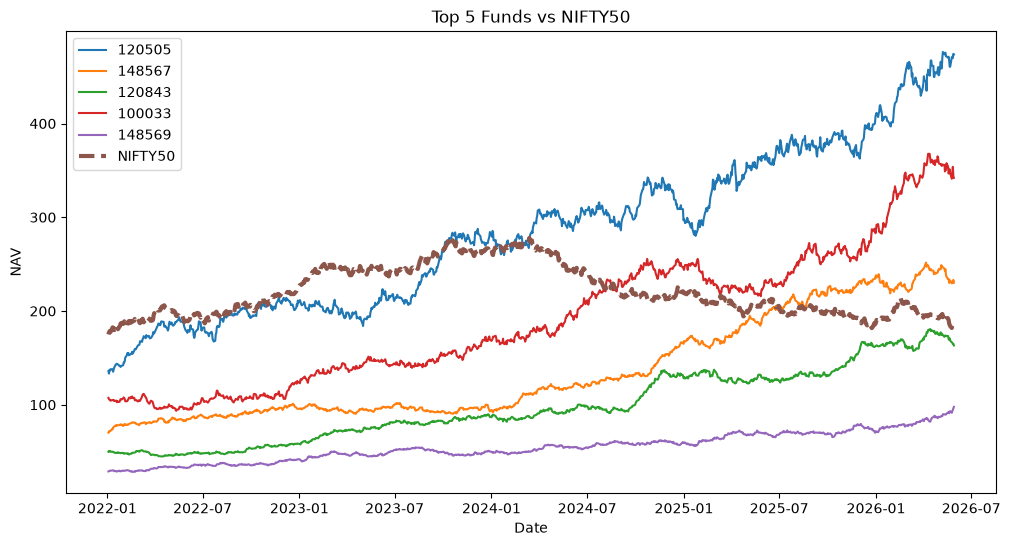

In [74]:
plt.figure(figsize=(12,6))

for fund in top5_codes:
    
    temp = top5_nav[
        top5_nav["amfi_code"]==fund
    ]
    
    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(fund)
    )

plt.plot(
    nifty50["date"],
    nifty50["close_value"]/100,
    linewidth=3,
    linestyle="--",
    label="NIFTY50"
)

plt.title("Top 5 Funds vs NIFTY50")

plt.xlabel("Date")

plt.ylabel("NAV")

plt.legend()

plt.show()

## Task 8: Benchmark Comparison of Top 5 Funds

### Objective
Compare the NAV performance of the top 5 mutual funds with the NIFTY50 benchmark over the available time period.

### Steps Performed
- Selected the top 5 funds based on the overall fund scorecard.
- Merged NAV history with benchmark index data.
- Plotted the NAV trend of each fund.
- Added the NIFTY50 benchmark for comparison.
- Analysed which funds outperformed the benchmark.

### Observation
- Fund **120505** showed the strongest NAV growth during the analysis period.
- Funds **100033** and **148567** also outperformed the benchmark.
- NIFTY50 displayed relatively stable growth compared to the top-performing funds.
- The comparison helps identify funds that generated better long-term returns than the benchmark.

In [75]:
tracking_error.to_csv(
    "../data/processed/tracking_error.csv"
)